Практическое задание «Модели ARMA»

Информация для студентов
Примерное время выполнения задания - 120 минут

Выполнив это задание, вы:
Отработаете навык построения модели ARIMA для временного ряда и прогнозирование с использованием классического машинного обучения (ML)

Инструменты и материалы, которые пригодятся для выполнения задания

    machinelearningmastery.com...th-python/
    machinelearningmastery.com...in-python/

Задание

Вам нужно провести эксперимент с моделью ARIMA для предсказания временного ряда.
Дополнительное задание (не обязательно к выполнению): провести аналогичный эксперимент с моделями из классического ML.
Инструкция к выполнению

    Выберите любой из 6-ти рядов из материалов (интереснее работать с рядами, у которых выраженная сезонность).
    Постройте модель ARIMA для этого ряда, аналогично материалам лекции, с поиском оптимальных параметров.
    Постройте график остатков предсказания ряда.
    *Дополнительное задание: постройте предсказание ряда с помощью классического ML. Поэкспериментируйте с фичами ряда (лагами).

Критерии оценки домашнего задания
Сохраните вашу работу в облаке, откройте файл для просмотра, вставьте ссылку в поле «Ссылка на решение» и нажмите «Отправить решение».
«Зачёт»

    Проведён эксперимент с ARIMA для одного из выбранных рядов;
    Найдены оптимальные параметры модели;
    Построен график остатков предсказания ряда.
    «На доработку»
    Не найдены оптимальные параметры модели (взяты случайные или нет обоснования выбранных параметров);
    Не построен график остатков предсказания ряда.
    «Незачёт» ставится в крайнем случае, если вы присылаете пустое или недоработанное задание во второй раз после отправки работы на доработку.



In [62]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tqdm
import statsmodels.api as sm
import statsmodels.tsa.api as smt

from math import sqrt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import adfuller
from scipy.stats import boxcox
from statsmodels.tsa.arima.model import ARIMA

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

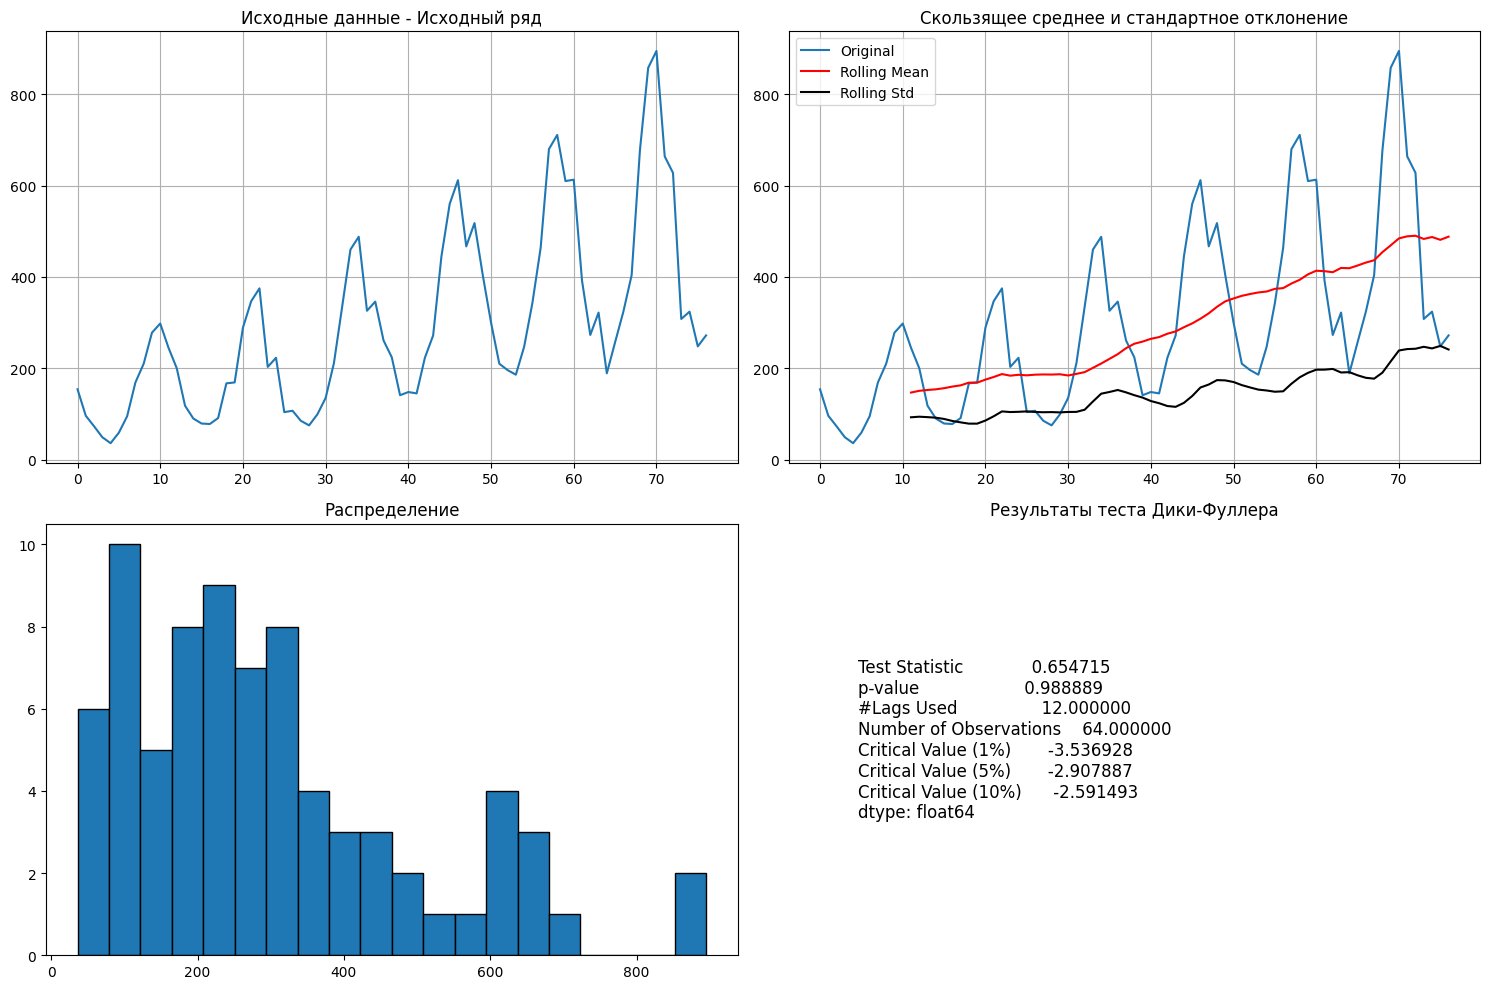


Результаты теста Дики-Фуллера:
Test Statistic             0.654715
p-value                    0.988889
#Lags Used                12.000000
Number of Observations    64.000000
Critical Value (1%)       -3.536928
Critical Value (5%)       -2.907887
Critical Value (10%)      -2.591493
dtype: float64

❌ p-value (0.9889) > 0.05 - Ряд НЕ стационарен


0.9888894205170052

In [63]:
def check_stationarity(timeseries, title):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    axes[0, 0].plot(timeseries)
    axes[0, 0].set_title(f'{title} - Исходный ряд')
    axes[0, 0].grid(True)
    
    rolmean = timeseries.rolling(window=12).mean()
    rolstd = timeseries.rolling(window=12).std()
    
    axes[0, 1].plot(timeseries, label='Original')
    axes[0, 1].plot(rolmean, color='red', label='Rolling Mean')
    axes[0, 1].plot(rolstd, color='black', label='Rolling Std')
    axes[0, 1].set_title('Скользящее среднее и стандартное отклонение')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    axes[1, 0].hist(timeseries, bins=20, edgecolor='black')
    axes[1, 0].set_title('Распределение')
    
    dftest = adfuller(timeseries.dropna(), autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], 
                        index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations'])
    
    for key, value in dftest[4].items():
        dfoutput[f'Critical Value ({key})'] = value
    
    axes[1, 1].axis('off')
    axes[1, 1].text(0.1, 0.5, str(dfoutput), fontsize=12, verticalalignment='center')
    axes[1, 1].set_title('Результаты теста Дики-Фуллера')
    
    plt.tight_layout()
    plt.show()
    
    print("\nРезультаты теста Дики-Фуллера:")
    print(dfoutput)
    
    if dftest[1] <= 0.05:
        print(f"\n✅ p-value ({dftest[1]:.4f}) <= 0.05 - Ряд стационарен")
    else:
        print(f"\n❌ p-value ({dftest[1]:.4f}) > 0.05 - Ряд НЕ стационарен")
    
    return dftest[1]
    
series = pd.read_csv('/home/slava/Documents/netology_ML/Временные ряды/материалы/data_sets/Series/monthly-sales-of-company-x-jan-6.csv')
check_stationarity(series['Count'], 'Исходные данные')

### Комментарии:
Согласно заданию мы берес нестационарный ряд с выраженной сезонностью

In [29]:
def tsplot(y, lags=None, figsize=(14, 8), style='bmh'):
    test_stationarity(y)
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
    with plt.style.context(style):
        plt.figure(figsize=figsize)
        layout = (5, 1)
        ts_ax = plt.subplot2grid(layout, (0, 0), rowspan=2)
        acf_ax = plt.subplot2grid(layout, (2, 0))
        pacf_ax = plt.subplot2grid(layout, (3, 0))
        qq_ax = plt.subplot2grid(layout, (4, 0))

        y.plot(ax=ts_ax, color='blue', label='Or')
        ts_ax.set_title('Original')

        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax, alpha=0.05)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax, alpha=0.05)
        sm.qqplot(y, line='s', ax=qq_ax)
        
        plt.tight_layout()
    return


def test_stationarity(timeseries):
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for [key, value] in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    print(dfoutput)

Успешно: order=(0, 0, 0), AIC=1125.96
Успешно: order=(0, 0, 1), AIC=1050.71
Успешно: order=(0, 0, 2), AIC=992.61
Успешно: order=(0, 1, 0), AIC=916.50
Успешно: order=(0, 1, 1), AIC=913.88
Успешно: order=(0, 1, 2), AIC=903.30
Успешно: order=(0, 2, 0), AIC=929.84
Успешно: order=(0, 2, 1), AIC=914.77
Успешно: order=(0, 2, 2), AIC=913.50
Успешно: order=(1, 0, 0), AIC=930.97
Успешно: order=(1, 0, 1), AIC=927.89
Успешно: order=(1, 0, 2), AIC=916.29
Успешно: order=(1, 1, 0), AIC=911.13
Успешно: order=(1, 1, 1), AIC=911.88
Успешно: order=(1, 1, 2), AIC=903.95
Успешно: order=(1, 2, 0), AIC=910.57
Успешно: order=(1, 2, 1), AIC=912.33
Успешно: order=(1, 2, 2), AIC=913.98
Успешно: order=(2, 0, 0), AIC=924.31
Успешно: order=(2, 0, 1), AIC=924.28
Успешно: order=(2, 0, 2), AIC=915.50
Успешно: order=(2, 1, 0), AIC=908.95
Успешно: order=(2, 1, 1), AIC=908.71
Успешно: order=(2, 1, 2), AIC=897.93
Успешно: order=(2, 2, 0), AIC=912.31
Успешно: order=(2, 2, 1), AIC=914.31
Успешно: order=(2, 2, 2), AIC=915.42

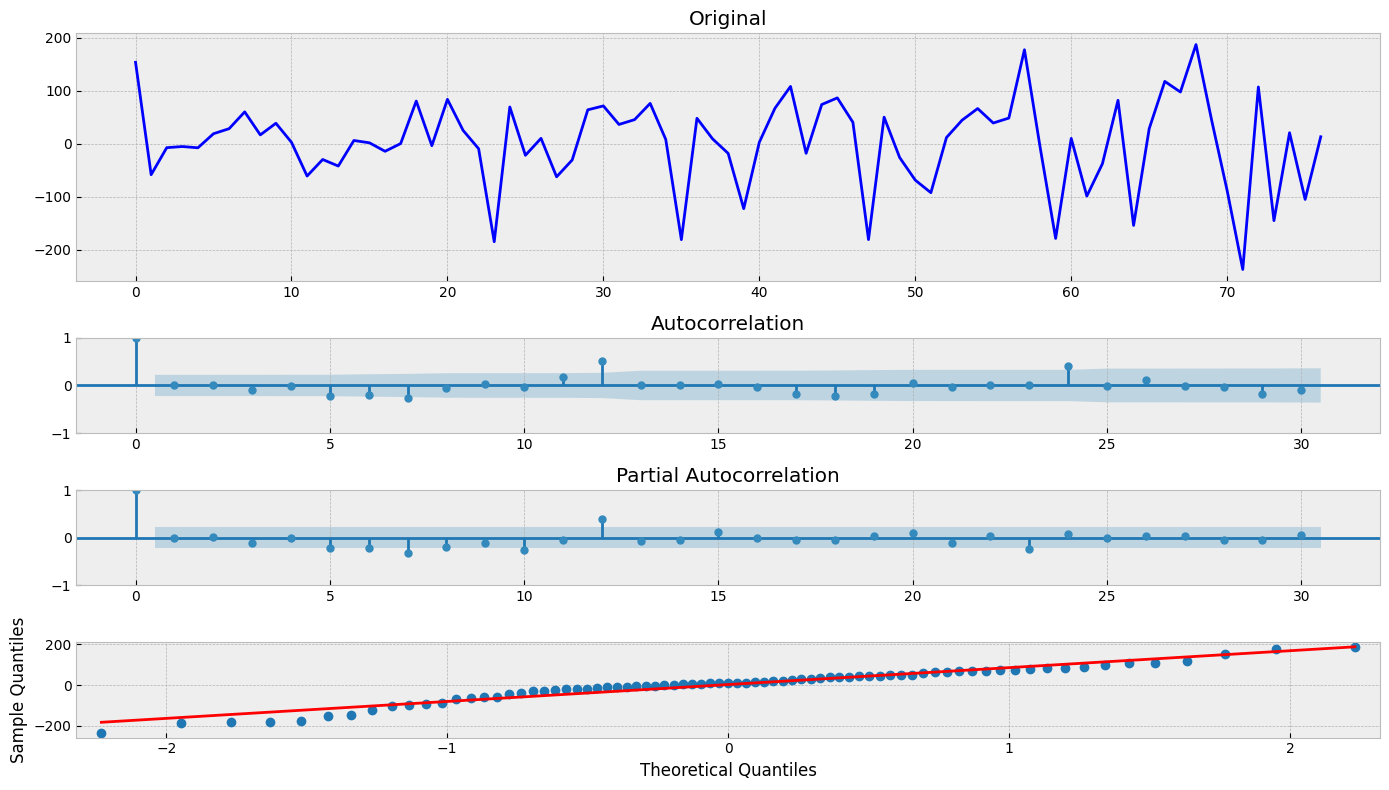

In [30]:
best_aic = np.inf 
best_order = None
best_mdl = None
successful_fits = 0

for i in range(3):
    for d in range(3):
        for j in range(3):
            try:
                tmp_mdl = ARIMA(series['Count'], order=(i, d, j), trend='n').fit()
                tmp_aic = tmp_mdl.aic
                successful_fits += 1
                print(f"Успешно: order={(i,d,j)}, AIC={tmp_aic:.2f}")
                if tmp_aic < best_aic:
                    best_aic = tmp_aic
                    best_order = (i, d, j)
                    best_mdl = tmp_mdl
            except Exception as e:
                print(f"Ошибка для order={(i,d,j)}: {e}")
                continue

print(f"Всего успешных подгонок: {successful_fits}")

if best_mdl is None:
    print("Не удалось подобрать ни одной модели!")
else:
    print('aic: {:6.5f} | order: {}'.format(best_aic, best_order))
    tsplot(best_mdl.resid, lags=30)

Успешно: order=(0, 0, 0), AIC=1125.96
Успешно: order=(0, 0, 1), AIC=1050.71
Успешно: order=(0, 0, 2), AIC=992.61
Успешно: order=(0, 0, 3), AIC=958.69
Успешно: order=(0, 0, 4), AIC=992.26
Успешно: order=(0, 0, 5), AIC=986.29
Успешно: order=(0, 1, 0), AIC=916.50
Успешно: order=(0, 1, 1), AIC=913.88
Успешно: order=(0, 1, 2), AIC=903.30
Успешно: order=(0, 1, 3), AIC=903.54
Успешно: order=(0, 1, 4), AIC=900.85
Успешно: order=(0, 1, 5), AIC=887.65
Успешно: order=(0, 2, 0), AIC=929.84
Успешно: order=(0, 2, 1), AIC=914.77
Успешно: order=(0, 2, 2), AIC=913.50
Успешно: order=(0, 2, 3), AIC=897.81
Успешно: order=(0, 2, 4), AIC=897.79
Успешно: order=(0, 2, 5), AIC=901.77
Успешно: order=(0, 3, 0), AIC=999.34
Успешно: order=(0, 3, 1), AIC=924.67
Успешно: order=(0, 3, 2), AIC=911.02
Успешно: order=(0, 3, 3), AIC=908.73
Успешно: order=(0, 3, 4), AIC=897.14
Успешно: order=(0, 3, 5), AIC=897.99
Успешно: order=(0, 4, 0), AIC=1078.42
Успешно: order=(0, 4, 1), AIC=992.64
Успешно: order=(0, 4, 2), AIC=923.2

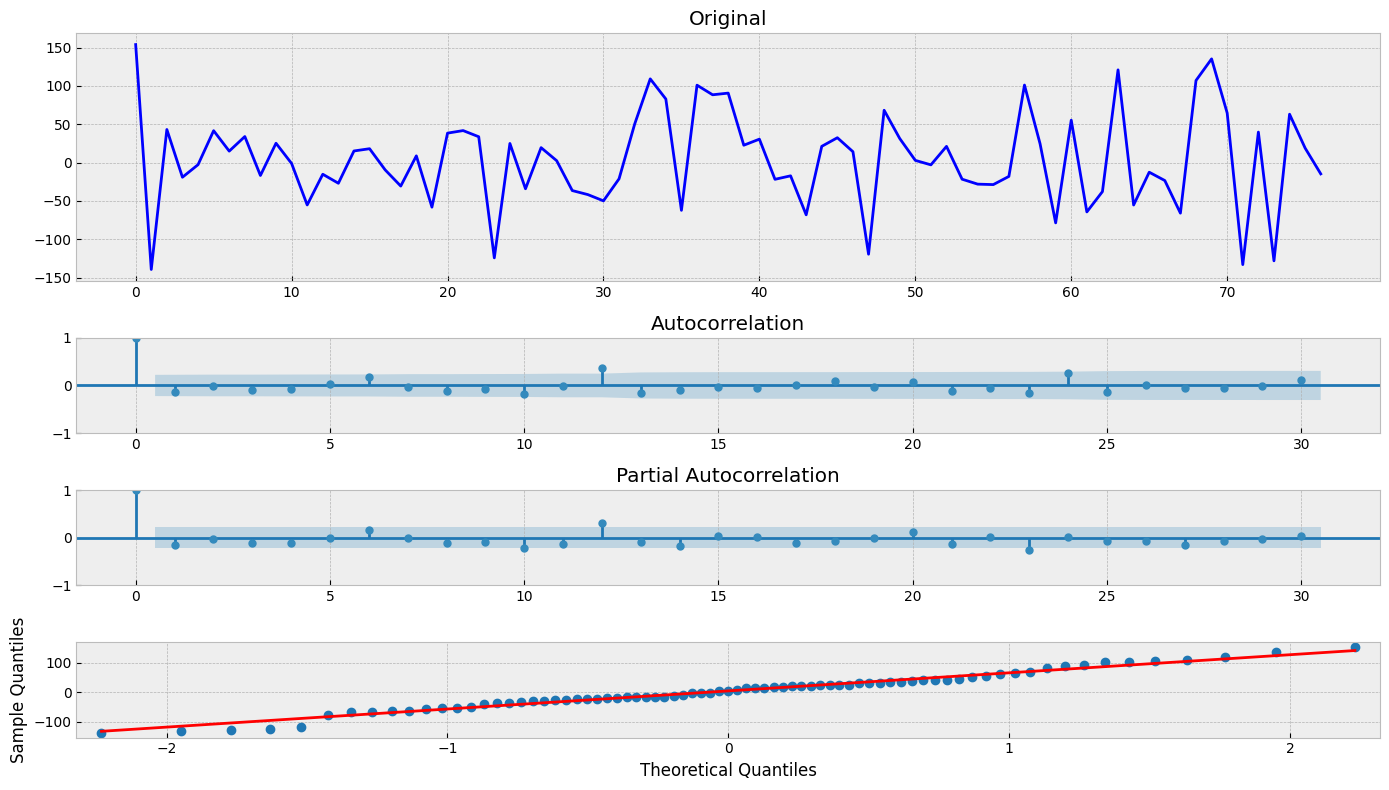

In [31]:
best_aic = np.inf 
best_order = None
best_mdl = None
successful_fits = 0

for i in range(6):
    for d in range(6):
        for j in range(6):
            try:
                tmp_mdl = ARIMA(series['Count'], order=(i, d, j), trend='n').fit()
                tmp_aic = tmp_mdl.aic
                successful_fits += 1
                print(f"Успешно: order={(i,d,j)}, AIC={tmp_aic:.2f}")
                if tmp_aic < best_aic:
                    best_aic = tmp_aic
                    best_order = (i, d, j)
                    best_mdl = tmp_mdl
            except Exception as e:
                print(f"Ошибка для order={(i,d,j)}: {e}")
                continue

print(f"Всего успешных подгонок: {successful_fits}")

if best_mdl is None:
    print("Не удалось подобрать ни одной модели!")
else:
    print('aic: {:6.5f} | order: {}'.format(best_aic, best_order))
    tsplot(best_mdl.resid, lags=30)

### Выводы:
Мы сразу получили хороший результат IC=897.93. При увеличении порядка получили ещё лучший AIC=854.05!
Ряд преобразовался в стационарный p-value = 0.3 и Test Statistic = -1.9.
Параметры модели 2,1,2:

    AR(2) - текущее значение зависит от значений 2 предыдущих периодов
    d=1 - одно дифференцирование
    MA(2) - текущее значение зависит от ошибок прогноза 2 предыдущих периодов


### Построение обычной модели регрессии: 

In [64]:
data.head()

,Month,Count
0,1965-01,154
1,1965-02,96
2,1965-03,73
3,1965-04,49
4,1965-05,36


In [65]:
df = pd.DataFrame(data)
df['Month'] = pd.to_datetime(df['Month'])

df['Year'] = df['Month'].dt.year
df['Month_Num'] = df['Month'].dt.month
df['Quarter'] = df['Month'].dt.quarter
df['DayOfYear'] = df['Month'].dt.dayofyear
df['Trend'] = range(len(df))

df[['Year', 'Month_Num', 'Quarter', 'DayOfYear', 'Count', 'Trend']].head()

,Year,Month_Num,Quarter,DayOfYear,Count,Trend
0,1965,1,1,1,154,0
1,1965,2,1,32,96,1
2,1965,3,1,60,73,2
3,1965,4,2,91,49,3
4,1965,5,2,121,36,4


In [67]:
feature_columns = ['Year', 'Month_Num', 'Quarter', 'DayOfYear', 'Trend']
X = df[feature_columns].values
y = df['Count'].values

train_size = int(len(X) * 0.8) 
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    predictions[name] = y_pred
    
    print(f"\n{name}:")
    print(f"  MAE: {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R2: {r2:.4f}")


Linear Regression:
  MAE: 132.6378
  RMSE: 155.2459
  R2: 0.5023

Ridge Regression:
  MAE: 166.7872
  RMSE: 183.8643
  R2: 0.3019

Random Forest:
  MAE: 158.4819
  RMSE: 170.7969
  R2: 0.3976

Gradient Boosting:
  MAE: 112.3655
  RMSE: 127.3713
  R2: 0.6650


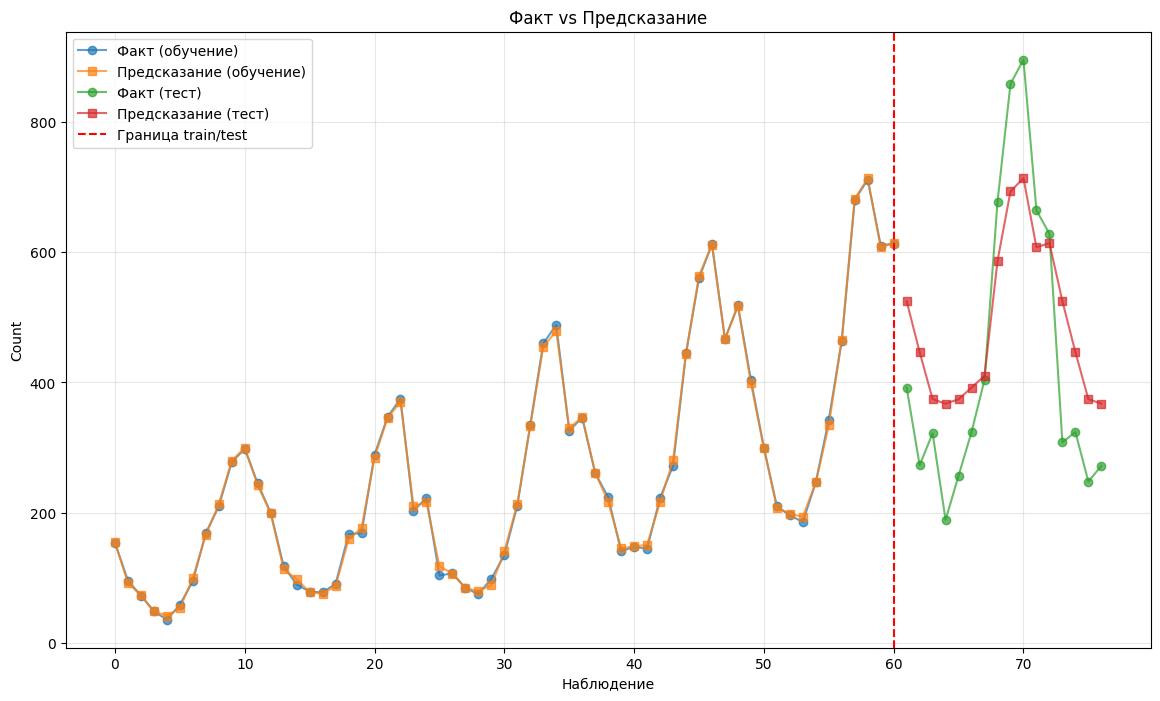

In [69]:
y_pred_train = models['Gradient Boosting'].predict(X_train)
y_pred_test = models['Gradient Boosting'].predict(X_test)

plt.figure(figsize=(14, 8))

plt.plot(range(len(y_train)), y_train, 'o-', label='Факт (обучение)', alpha=0.7)
plt.plot(range(len(y_train)), y_pred_train, 's-', label='Предсказание (обучение)', alpha=0.7)
plt.plot(range(len(y_train), len(y_train) + len(y_test)), y_test, 'o-', label='Факт (тест)', alpha=0.7)
plt.plot(range(len(y_train), len(y_train) + len(y_test)), y_pred_test, 's-', label='Предсказание (тест)', alpha=0.7)
plt.axvline(x=len(y_train)-1, color='red', linestyle='--', label='Граница train/test')
plt.xlabel('Наблюдение')
plt.ylabel('Count')
plt.title('Факт vs Предсказание')
plt.legend()
plt.grid(True, alpha=0.3)

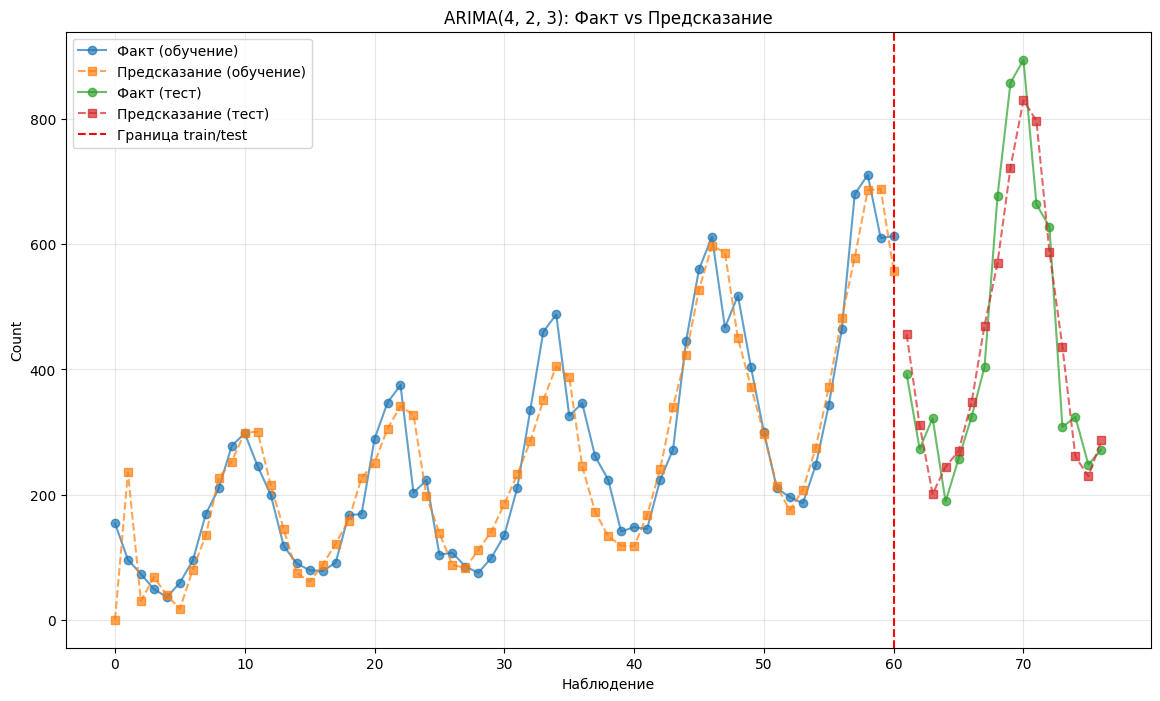

In [59]:
train_size = int(len(data['Count']) * 0.8)
train_data = data['Count'][:train_size]
test_data = data['Count'][train_size:]

train_pred = best_mdl.get_prediction(start=0, end=len(train_data)-1)
y_pred_train = train_pred.predicted_mean

test_pred = best_mdl.get_prediction(start=len(train_data), end=len(series['Count'])-1, dynamic=False)
y_pred_test = test_pred.predicted_mean

plt.figure(figsize=(14, 8))

train_index = range(len(train_data))
test_index = range(len(train_data), len(train_data) + len(test_data))

plt.plot(train_index, train_data.values, 'o-', label='Факт (обучение)', alpha=0.7)
plt.plot(train_index, y_pred_train.values, 's--', label='Предсказание (обучение)', alpha=0.7)
plt.plot(test_index, test_data.values, 'o-', label='Факт (тест)', alpha=0.7)
plt.plot(test_index, y_pred_test.values, 's--', label='Предсказание (тест)', alpha=0.7)
plt.axvline(x=len(train_data)-1, color='red', linestyle='--', label='Граница train/test')
plt.xlabel('Наблюдение')
plt.ylabel('Count')
plt.title(f'ARIMA{best_order}: Факт vs Предсказание')
plt.legend()
plt.grid(True, alpha=0.3)

## Выводы:
Было весело, а это главное!
Результат с ходу получился не плохой 0.83 на линейной модели. Потом я понял, что кажется я где-то ошибся? И точно! Нельзя делить временной ряд через train_test_split! Но тогда я получил 0.5, что вообще не о чем. Я сделал для нескольких моделей и выбрал лучшую Gradient Boosting, но даже она уступает с головой ARIMA.